In [1]:
import numpy as np
from matplotlib import pyplot as plt

from hf_scores import isruc_age, isruc_sex

ISRUC age: [15.62856776 15.20529402 15.05531492 14.80840096 14.54957617 14.23630311
 13.91833903 13.87193452 13.94962917 13.95345639 14.02356074 14.13095405
 14.35548116 14.35367473]
ISRUC sex: [0.49965036 0.49552632 0.52760412 0.56666677 0.54288117 0.55417051
 0.59529117 0.5879636  0.58733875 0.589269   0.58264924 0.57817078
 0.56121454 0.57809093]


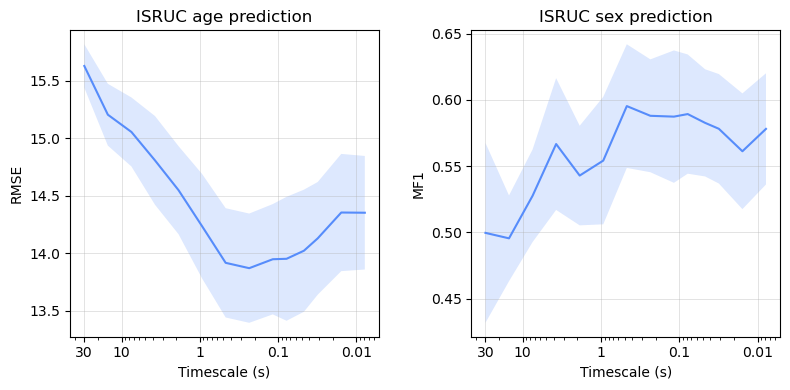

In [2]:
_, axes = plt.subplots(1, 2, figsize=(8, 4))
axes = axes.flatten()

# panel ISRUC age prediction
scores_to_plot = {}
for i, (model_run, rmses_model) in enumerate(isruc_age.items()):
    for sr in rmses_model.keys():
        if sr not in scores_to_plot:
            scores_to_plot[sr] = []
        scores_to_plot[sr].append(rmses_model[sr])

scores_to_plot = {sr: np.array(v) for sr, v in scores_to_plot.items()}
means_to_plot = np.array([np.mean(v) for v in scores_to_plot.values()])
print(f"ISRUC age: {means_to_plot}")
stds_to_plot = np.array([np.std(v) for v in scores_to_plot.values()])
x_axis = [30 / k for k in scores_to_plot.keys()]
axes[0].plot(x_axis, means_to_plot, label="AnySleep with\nrandom forest regressor")
axes[0].fill_between(x_axis, means_to_plot - stds_to_plot, means_to_plot + stds_to_plot, alpha=0.2)
axes[0].set_xscale("log")

axes[0].set_xticks([1e-2, 1e-1, 1, 10, 30], [1e-2, 1e-1, 1, 10, 30])
axes[0].grid(axis="x")
axes[0].set_xlabel("Timescale (s)")
axes[0].set_ylabel("RMSE")
axes[0].set_title("ISRUC age prediction")

# panel ISRUC sex prediction
scores_to_plot = {}
for i, (model_run, mf1_scores_model) in enumerate(isruc_sex.items()):
    for sr in mf1_scores_model.keys():
        if sr not in scores_to_plot:
            scores_to_plot[sr] = []
        scores_to_plot[sr].append(mf1_scores_model[sr])

scores_to_plot = {sr: np.array(v) for sr, v in scores_to_plot.items()}
means_to_plot = np.array([np.mean(v) for v in scores_to_plot.values()])
print(f"ISRUC sex: {means_to_plot}")
stds_to_plot = np.array([np.std(v) for v in scores_to_plot.values()])
axes[1].plot(x_axis, means_to_plot, label="AnySleep with\nrandom forest classifier")
axes[1].fill_between(x_axis, means_to_plot - stds_to_plot, means_to_plot + stds_to_plot, alpha=0.2)
axes[1].set_xscale("log")

axes[1].set_xticks([1e-2, 1e-1, 1, 10, 30], [1e-2, 1e-1, 1, 10, 30])
axes[1].grid(axis="x")
axes[1].set_xlabel("Timescale (s)")
axes[1].set_ylabel("MF1")
axes[1].set_title("ISRUC sex prediction")

for ax in axes:
    # flip x axis
    ax.invert_xaxis()
    ax.tick_params(
        axis='both',
        which='both',
        bottom=True,
        top=False,
        left=True, )
    ax.grid(axis="y")

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.savefig("fig_s3.svg", bbox_inches="tight")
plt.show()